In [ ]:
%load_ext autoreload
%autoreload 2

import jax
import healpy as hp
import numpy as np
import healpy as hp
import pysm3

from furax.comp_sep import spectral_cmb_variance , get_clusters , optimize

import jax
import jax.numpy as jnp
from jax import ShapeDtypeStruct

from furax._base.blocks import BlockDiagonalOperator, BlockRowOperator
from furax._base.core import HomothetyOperator, IdentityOperator
from furax.landscapes import StokesPyTree, ValidStokesType, HealpixLandscape , StokesLandscape
from furax.tree import as_structure
from furax.operators.sed import CMBOperator, DustOperator, SynchrotronOperator, MixingMatrixOperator
import operator
from math import prod
import numpy as np
from functools import partial
import matplotlib.pyplot as plt

import os
import pickle

from furax.comp_sep import spectral_cmb_variance , get_clusters , optimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
GAL020 = np.load("GAL_PlanckMasks_64.npz")['GAL020']
GAL040 = np.load("GAL_PlanckMasks_64.npz")['GAL040']
GAL060 = np.load("GAL_PlanckMasks_64.npz")['GAL060']

In [6]:
nside = 64
npixel = 12 * nside**2
stokes_type =  'QU'
frequency_count = 15
nu = jnp.linspace(40., 402., frequency_count)

In [7]:
comp_keys = jax.random.split(jax.random.PRNGKey(0), 3)
stokes_cls = StokesPyTree.class_for(stokes_type)

sky = {
    'cmb': stokes_cls.normal(comp_keys[0], (npixel,)),
    'dust': stokes_cls.normal(comp_keys[1], (npixel,)),
    'synchrotron': stokes_cls.normal(comp_keys[2], (npixel,)),
}

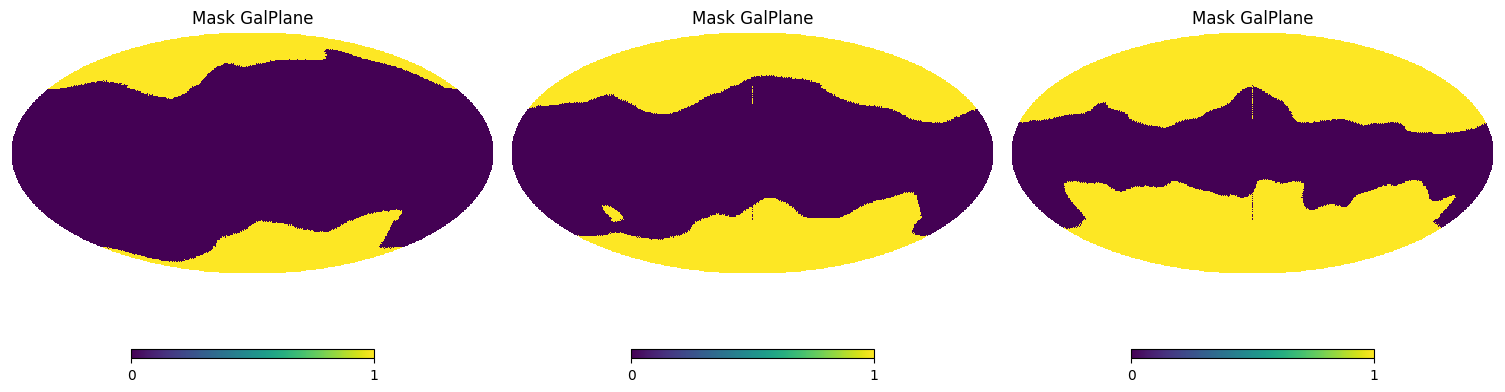

In [9]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(15, 15))
hp.mollview(GAL020, title='Mask GalPlane' , sub=(1 ,3 , 1))
hp.mollview(GAL040, title='Mask GalPlane' , sub=(1 ,3 , 2))
hp.mollview(GAL060, title='Mask GalPlane' , sub=(1 ,3, 3))
plt.show()


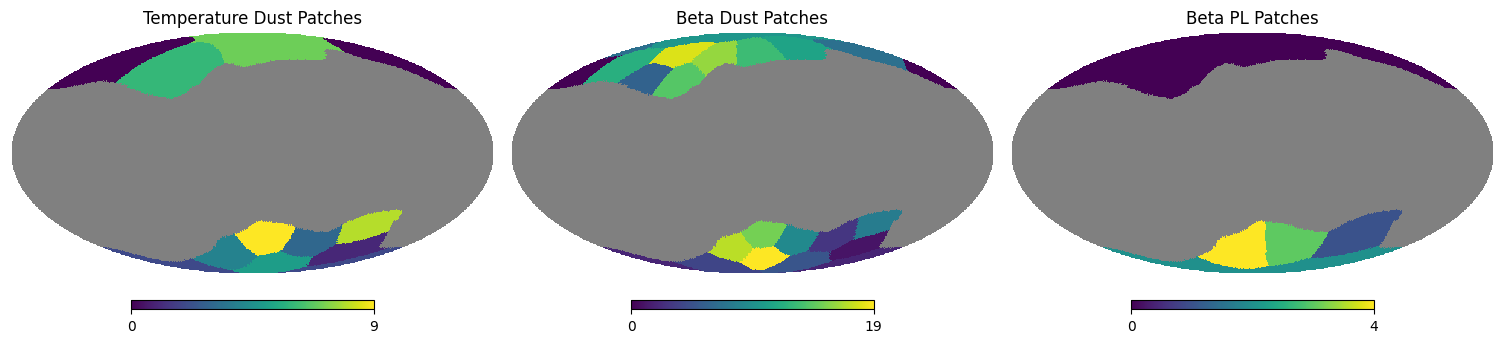

In [10]:
temp_dust_patches_count = 10
beta_dust_patches_count = 20
beta_pl_patches_count = 5


temp_dust_patch_indices = get_clusters(GAL020, temp_dust_patches_count , jax.random.PRNGKey(0))
beta_dust_patch_indices = get_clusters(GAL020, beta_dust_patches_count , jax.random.PRNGKey(0))
beta_pl_patch_indices = get_clusters(GAL020, beta_pl_patches_count , jax.random.PRNGKey(0))

params = {
    'temp_dust': jnp.linspace(10., 30., temp_dust_patches_count),
    'beta_dust': jnp.linspace(1.5, 2.5, beta_dust_patches_count),
    'beta_pl': jnp.linspace(-3., -2., beta_pl_patches_count),
}

patch_indices = {
    'temp_dust_patches': temp_dust_patch_indices,
    'beta_dust_patches': beta_dust_patch_indices,
    'beta_pl_patches': beta_pl_patch_indices,
}

# Set up subplots
fig = plt.figure(figsize=(15, 5))
# Plot each map
hp.mollview(temp_dust_patch_indices, title='Temperature Dust Patches', sub=(1, 3, 1))
hp.mollview(beta_dust_patch_indices, title='Beta Dust Patches', sub=(1, 3, 2))
hp.mollview(beta_pl_patch_indices, title='Beta PL Patches', sub=(1, 3, 3))

# Display the plot
plt.show()

In [11]:
@jax.jit
def get_cutout_from_mask(ful_map, indices):
    return jnp.take(ful_map, indices)


@jax.jit
def from_cutout_to_fullmap(goodpix, indices, ful_map):
    return ful_map.at[indices].set(goodpix)

indices, = jnp.where(GAL020 == 1)

masked_sky = jax.tree.map(
    lambda full_map: get_cutout_from_mask(full_map, indices), sky)
masked_clusters = jax.tree.map(lambda full_map: get_cutout_from_mask(full_map, indices).astype(jnp.int32),
                               patch_indices)

In [ ]:
from furax.comp_sep import spectral_cmb_variance

dust_nu0 = 150.0
synchrotron_nu0 = 20.0

spectral_cmb_variance = partial(
    spectral_cmb_variance, dust_nu0=dust_nu0, synchrotron_nu0=synchrotron_nu0
)

nside = 64
stokes = 'QU'
in_structure = StokesPyTree.class_for('QU').structure_for((int(jnp.sum(GAL020)),))

cmb = CMBOperator(nu, in_structure=in_structure)
dust = DustOperator(
    nu,
    frequency0=dust_nu0,
    temperature=params['temp_dust'],
    temperature_patch_indices=masked_clusters['temp_dust_patches'],
    beta=params['beta_dust'],
    beta_patch_indices=masked_clusters['beta_dust_patches'],
    in_structure=in_structure,
)
synchrotron = SynchrotronOperator(
    nu,
    frequency0=synchrotron_nu0,
    beta_pl=params['beta_pl'],
    beta_pl_patch_indices=masked_clusters['beta_pl_patches'],
    in_structure=in_structure,
)

A = MixingMatrixOperator(cmb=cmb, dust=dust, synchrotron=synchrotron)
d = A(masked_sky)
N = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)

wrong_params = jax.tree.map(lambda x : jax.random.normal(jax.random.PRNGKey(0), x.shape) , params)


In [17]:
good_var = spectral_cmb_variance(params , nu=nu , d=d , N=N , patch_indices=masked_clusters) 
bad_var = spectral_cmb_variance(wrong_params , nu=nu , d=d , N=N , patch_indices=masked_clusters)

print(f"Good variance : {good_var} , Bad variance : {bad_var} \nGood variance is better than bad variance : {good_var < bad_var}")

Good variance : 1.9697431244935113 , Bad variance : 156.12917759947803 
Good variance is better than bad variance : True


In [ ]:
from furax.comp_sep import optimize
import optax
import optax.tree_utils as otu

solver = optax.lbfgs()

final_params, final_state = optimize(
    params, spectral_cmb_variance, solver, max_iter=100, tol=1e-4, nu=nu, N=N, d=d , patch_indices=masked_clusters
)

print(
    f"Final parameters: {final_params}, number of evaluations: {otu.tree_get(final_state, 'count')}"
)
print(f'Initial Value: {spectral_cmb_variance(final_params , nu=nu, N=N, d=d , patch_indices=patch_indices)}')

Final parameters: {'beta_dust': Array([1.50208796, 1.55383625, 1.60829174, 1.65703741, 1.71100953,
       1.7639962 , 1.81715322, 1.87095487, 1.92019669, 1.9738132 ,
       2.02505653, 2.07783408, 2.12818528, 2.18337667, 2.23809915,
       2.28970386, 2.34450612, 2.39190197, 2.44540816, 2.49878606],      dtype=float64), 'beta_pl': Array([-3.00000438, -2.74999778, -2.50001643, -2.24996229, -1.99997619],      dtype=float64), 'temp_dust': Array([ 9.99988224, 12.22239735, 14.44461746, 16.66667978, 18.88880907,
       21.11107763, 23.33334148, 25.55557695, 27.77776182, 29.99999414],      dtype=float64)}, number of evaluations: 2
Initial Value: 1.9947193888433687


In [36]:
diff = jax.tree.map(lambda x , y: jnp.abs(x - y) , final_params , params)
print(f'Difference: {diff}')
jax.tree.all(jax.tree.map(lambda x , y: jnp.allclose(x , y , atol=1e-2) , final_params , params))

Difference: {'beta_dust': Array([0.00208796, 0.00120467, 0.00302858, 0.00085733, 0.00048321,
       0.0008383 , 0.00136375, 0.00253382, 0.00085594, 0.00012899,
       0.00125926, 0.00111329, 0.00339366, 0.00083386, 0.00125705,
       0.00023017, 0.00240085, 0.00283487, 0.00196026, 0.00121394],      dtype=float64), 'beta_pl': Array([4.38208262e-06, 2.21737820e-06, 1.64254936e-05, 3.77088774e-05,
       2.38053082e-05], dtype=float64), 'temp_dust': Array([1.17761128e-04, 1.75128256e-04, 1.73011968e-04, 1.31122569e-05,
       7.98168533e-05, 3.34795923e-05, 8.15109808e-06, 2.13906802e-05,
       1.59535912e-05, 5.85891484e-06], dtype=float64)}


True

In [ ]:
import jaxopt

scipy_solver = jaxopt.ScipyMinimize(fun=spectral_cmb_variance, method='TNC', jit=True, tol=1e-10)
result = scipy_solver.run(wrong_params, nu=nu, N=N, d=d , patch_indices=masked_clusters)
result.params

/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),
jax.pure_callback failed
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/jax/_src/callback.py", line 94, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/equinox/_errors.py", line 89, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunatel

XlaRuntimeError: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/runpy.py", line 86, in _run_code
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/asyncio/base_events.py", line 1896, in _run_once
  File "/home/wass

In [49]:
 jax.tree.map(lambda x , y: jnp.max(jnp.abs(x - y)) , result.params , params)


{'beta_dust': Array(0.0080109, dtype=float64),
 'beta_pl': Array(9.72272043e-05, dtype=float64),
 'temp_dust': Array(0.01139654, dtype=float64)}

In [51]:
diff = jax.tree.map(lambda x , y: jnp.max(jnp.abs(x - y)) , result.params , params)
print(f'Difference: {diff}')
jax.tree.all(jax.tree.map(lambda x , y: jnp.allclose(x , y , atol=1e-1) , result.params , params))

Difference: {'beta_dust': Array(0.0080109, dtype=float64), 'beta_pl': Array(9.72272043e-05, dtype=float64), 'temp_dust': Array(0.01139654, dtype=float64)}


True

In [53]:
final_params, final_state = optimize(
    wrong_params, spectral_cmb_variance, solver, max_iter=100, tol=1e-10, nu=nu, N=N, d=d , patch_indices=patch_indices
)

print(
    f"Final parameters: {final_params}, number of evaluations: {otu.tree_get(final_state, 'count')}"
)
print(f'Initial Value: {spectral_cmb_variance(final_params , nu=nu, N=N, d=d , patch_indices=patch_indices)}')

E1202 01:46:02.442394   91321 pjrt_stream_executor_client.cc:3085] Execution of replica 0 failed: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/runpy.py", line 86, in _run_code
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
  File "/home/wassim/micromamba/envs/jax/l

XlaRuntimeError: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/runpy.py", line 86, in _run_code
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
  File "/home/wassim/micromamba/envs/jax/lib/python3.10/asyncio/base_events.py", line 1896, in _run_once
  File "/home/wass

In [14]:
jax.tree.reduce(
    max, jax.tree.map(lambda x: jnp.max(x), jax.grad(neg_log_prob)(best_params, patch_indices, d))
)

Array(0.00052783, dtype=float64)

In [15]:
wrong_patches = jax.tree.map(
    lambda x: jax.random.permutation(jax.random.PRNGKey(2), x), patch_indices
)
wrong_params = jax.tree.map(lambda x: x + jax.random.normal(jax.random.PRNGKey(3)), best_params)
print(
    f'ALl pixels parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(all_pixels_param,all_patches,d)))}'
)
print(
    f'Wrong parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(wrong_params,patch_indices,d)))}'
)
print(
    f'Wrong patches grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(best_params,wrong_patches,d)))}'
)
print(
    f'Wrong patches and parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(wrong_params,wrong_patches,d)))}'
)
print(
    f'Correct parameters grad {jax.tree.reduce(max, jax.tree.map(lambda x: jnp.max(x) , jax.grad(neg_log_prob)(best_params,patch_indices,d)))}'
)

ALl pixels parameters grad 0.00046405290652758814
Wrong parameters grad -99.67543128968614
Wrong patches grad 28834.963675814608
Wrong patches and parameters grad 23768.069199521808
Correct parameters grad 0.0005278250288441151


In [16]:
grads = jax.grad(neg_log_prob)(best_params, patch_indices, d)

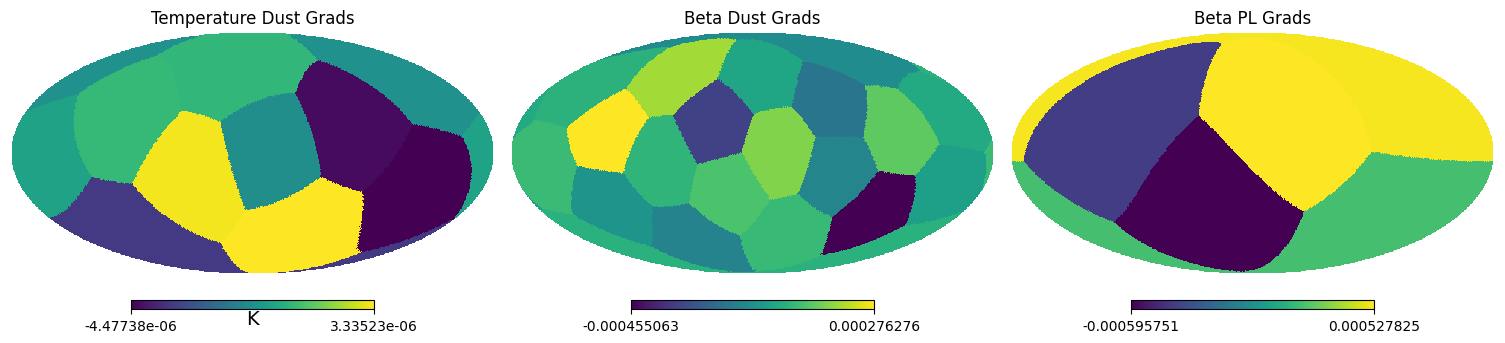

In [17]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Create maps for each parameter based on patches and their assigned values
temp_dust_map = grads['temp_dust'][temp_dust_patch_indices]
beta_dust_map = grads['beta_dust'][beta_dust_patch_indices]
beta_pl_map = grads['beta_pl'][beta_pl_patch_indices]

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit='K')
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit='')
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit='')

# Display the combined plot
plt.show()

In [18]:
all_pixel_grads = jax.grad(neg_log_prob)(all_pixels_param, all_patches, d)

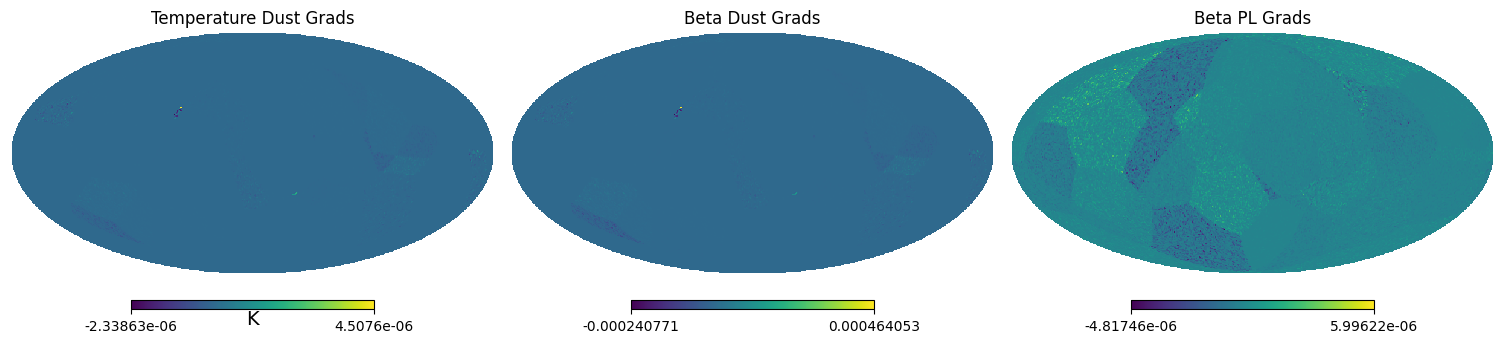

In [19]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Create maps for each parameter based on patches and their assigned values
temp_dust_map = all_pixel_grads['temp_dust']
beta_dust_map = all_pixel_grads['beta_dust']
beta_pl_map = all_pixel_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit='K')
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit='')
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit='')

# Display the combined plot
plt.show()

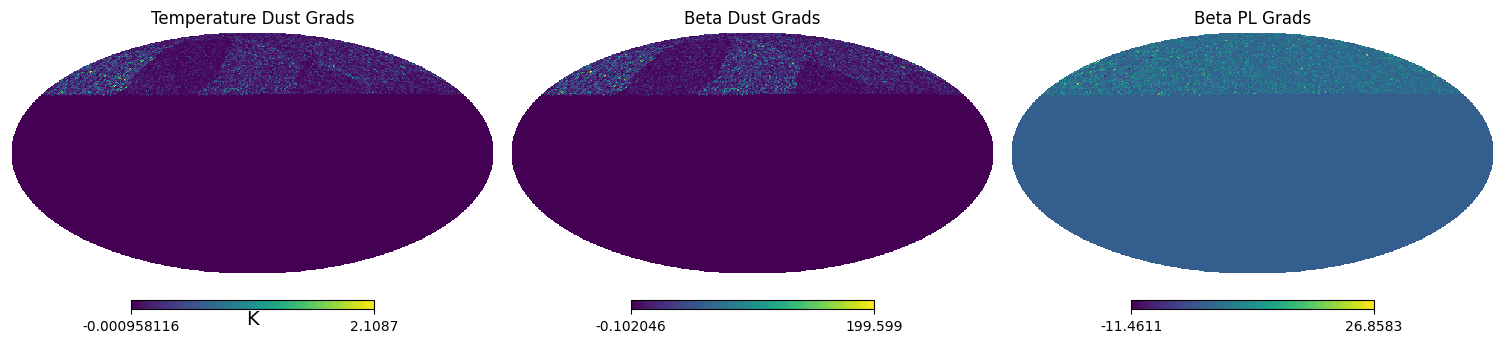

In [25]:
all_pixels_wrong = jax.tree.map(lambda x: x.at[:10000].add(1.0), all_pixels_param)
all_pixels_wrong_grads = jax.grad(neg_log_prob)(all_pixels_wrong, all_patches, d)

temp_dust_map = all_pixels_wrong_grads['temp_dust']
beta_dust_map = all_pixels_wrong_grads['beta_dust']
beta_pl_map = all_pixels_wrong_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit='K')
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit='')
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit='')

# Display the combined plot
plt.show()

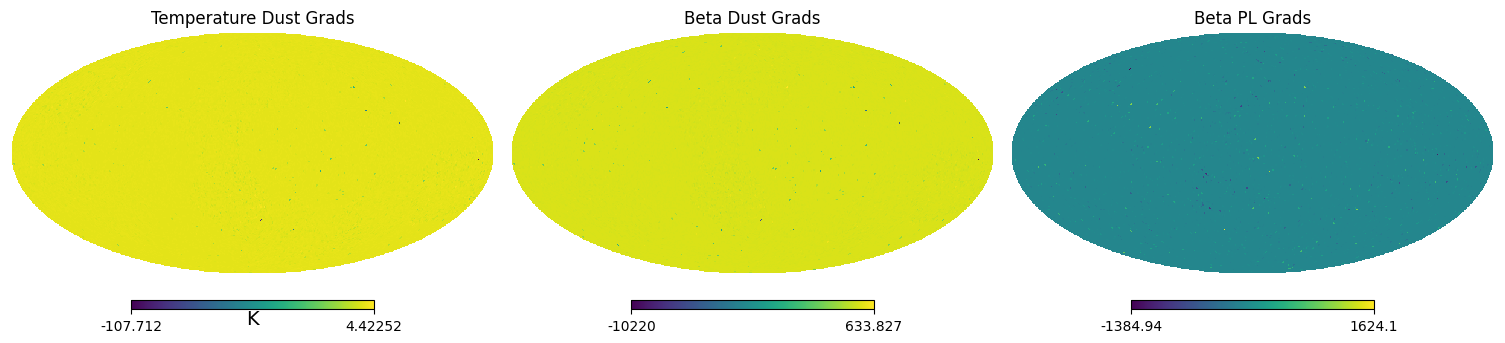

In [24]:
all_pixels_wrong = jax.tree.map(
    lambda x: x + jax.random.normal(jax.random.PRNGKey(3), x.shape), all_pixels_param
)
all_pixels_wrong_grads = jax.grad(neg_log_prob)(all_pixels_wrong, all_patches, d)

temp_dust_map = all_pixels_wrong_grads['temp_dust']
beta_dust_map = all_pixels_wrong_grads['beta_dust']
beta_pl_map = all_pixels_wrong_grads['beta_pl']

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_map, title='Temperature Dust Grads', sub=(1, 3, 1), unit='K')
hp.mollview(beta_dust_map, title='Beta Dust Grads', sub=(1, 3, 2), unit='')
hp.mollview(beta_pl_map, title='Beta PL Grads', sub=(1, 3, 3), unit='')

# Display the combined plot
plt.show()

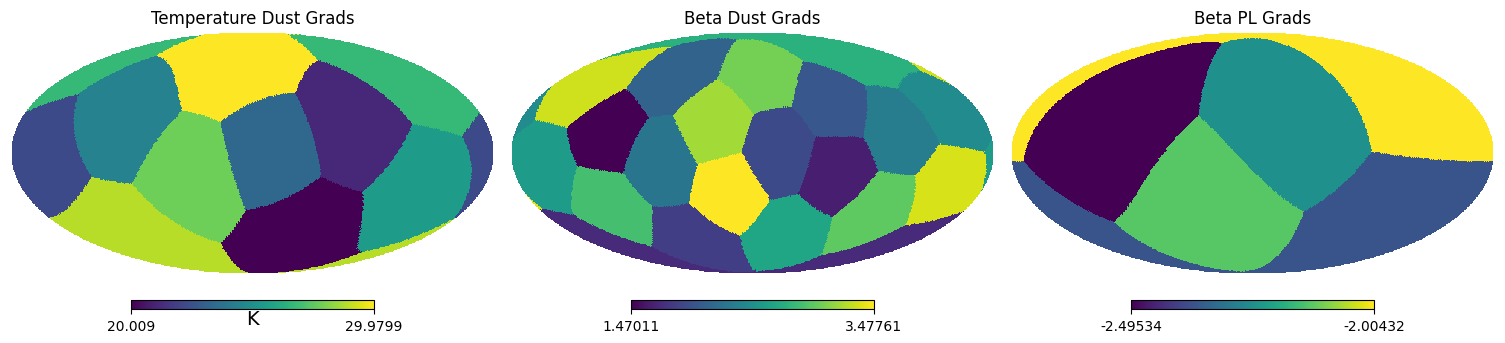

In [10]:
all_pixels_wrong = jax.tree.map(
    lambda x: x + jax.random.normal(jax.random.PRNGKey(3), x.shape), all_pixels_param
)


def average_grads(grads, patch_indices, patch_count):
    for patch_index in range(patch_count):
        grads = grads.at[np.where(patch_indices == patch_index)].set(
            jnp.mean(grads[np.where(patch_indices == patch_index)])
        )

    return grads


def uncluster(grads, patch_indices, patch_count):
    vals = jnp.zeros(patch_count)
    for patch_index in range(patch_count):
        vals = vals.at[patch_index].set(jnp.mean(grads[np.where(patch_indices == patch_index)]))

    return vals


temp_dust_grads = average_grads(
    all_pixels_wrong['temp_dust'], temp_dust_patch_indices, temp_dust_patches_count
)
beta_dust_grads = average_grads(
    all_pixels_wrong['beta_dust'], beta_dust_patch_indices, beta_dust_patches_count
)
beta_pl_grads = average_grads(
    all_pixels_wrong['beta_pl'], beta_pl_patch_indices, beta_pl_patches_count
)

fig = plt.figure(figsize=(15, 5))

# Plot each map in a subplot
hp.mollview(temp_dust_grads, title='Temperature Dust Grads', sub=(1, 3, 1), unit='K')
hp.mollview(beta_dust_grads, title='Beta Dust Grads', sub=(1, 3, 2), unit='')
hp.mollview(beta_pl_grads, title='Beta PL Grads', sub=(1, 3, 3), unit='')

# Display the combined plot
plt.show()

In [29]:
wrong_all_params = jax.tree.map(
    lambda x: x + jax.random.normal(jax.random.PRNGKey(3)), all_pixels_param
)

In [31]:
import jaxopt
from furax._base.config import ConfigState, Config
import lineax as lx

with Config(solver=lx.CG(rtol=1e-6, atol=1e-6, max_steps=6000)):
    solver = jaxopt.ScipyMinimize(fun=neg_log_prob, method='TNC', maxiter=1000, jit=True, tol=1e-10)
    %timeit  solver.run(best_params,patch_indices, d).params['beta_pl'].block_until_ready()

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),
/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


16.7 s ± 5.36 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [32]:
optimized_params = solver.run(best_params, patch_indices, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(f"Optimized params beta_dust \n{optimized_params['beta_dust']}")
print('-' * 50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(f"Optimized params beta_pl \n{optimized_params['beta_pl']}")
print('-' * 50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(f"Optimized params temp_dust \n{optimized_params['temp_dust']}")

Best params beta_dust 
[1.5        1.60526316 1.71052632 1.81578947 1.92105263 2.02631579
 2.13157895 2.23684211 2.34210526 2.44736842 2.55263158 2.65789474
 2.76315789 2.86842105 2.97368421 3.07894737 3.18421053 3.28947368
 3.39473684 3.5       ]
Optimized params beta_dust 
[1.50000023 1.60526304 1.71051917 1.81578928 1.92105327 2.02631443
 2.1315798  2.23684216 2.3421052  2.44736759 2.55263132 2.65789463
 2.76315862 2.86842138 2.97368314 3.07894698 3.18421242 3.28947295
 3.39473658 3.49999975]
--------------------------------------------------
Best params beta_pl 
[-2.5   -2.375 -2.25  -2.125 -2.   ]
Optimized params beta_pl 
[-2.49999992 -2.37499954 -2.25000005 -2.12499867 -2.00000102]
--------------------------------------------------
Best params temp_dust 
[20.         21.11111111 22.22222222 23.33333333 24.44444444 25.55555556
 26.66666667 27.77777778 28.88888889 30.        ]
Optimized params temp_dust 
[20.00001113 21.11113845 22.22222584 23.33332581 24.44445632 25.55555794
 26.

In [ ]:
with Config(solver=lx.CG(rtol=1e-2, atol=1e-2, max_steps=60000)):
    %time optimized_params = solver.run(wrong_all_params,all_patches, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(
    f"Optimized params beta_dust \n{uncluster(optimized_params['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)}"
)
print('-' * 50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(
    f"Optimized params beta_pl \n{uncluster(optimized_params['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)}"
)
print('-' * 50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(
    f"Optimized params temp_dust \n{uncluster(optimized_params['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)}"
)

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


In [14]:
optimized_params = solver.run(all_pixels_param, all_patches, d).params
print(f"Best params beta_dust \n{best_params['beta_dust']}")
print(
    f"Optimized params beta_dust \n{uncluster(optimized_params['beta_dust'], beta_dust_patch_indices, beta_dust_patch_count)}"
)
print('-' * 50)
print(f"Best params beta_pl \n{best_params['beta_pl']}")
print(
    f"Optimized params beta_pl \n{uncluster(optimized_params['beta_pl'], beta_pl_patch_indices, beta_pl_patch_count)}"
)
print('-' * 50)
print(f"Best params temp_dust \n{best_params['temp_dust']}")
print(
    f"Optimized params temp_dust \n{uncluster(optimized_params['temp_dust'], temp_dust_patch_indices, temp_dust_patch_count)}"
)

/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),


Best params beta_dust 
[1.5        1.60526316 1.71052632 1.81578947 1.92105263 2.02631579
 2.13157895 2.23684211 2.34210526 2.44736842 2.55263158 2.65789474
 2.76315789 2.86842105 2.97368421 3.07894737 3.18421053 3.28947368
 3.39473684 3.5       ]


NameError: name 'beta_dust_patch_count' is not defined

In [ ]:
params = {
    'temp_dust': best_params['temp_dust']
    + jax.random.normal(jax.random.PRNGKey(1), (temp_dust_patch_count,)) * 3,
    'beta_dust': best_params['beta_dust']
    + jax.random.normal(jax.random.PRNGKey(2), (beta_dust_patch_count,)) * 3,
    'beta_pl': best_params['beta_pl']
    + jax.random.normal(jax.random.PRNGKey(3), (beta_pl_patch_count,)) * 3,
}

print(f'changed params')
print(params['temp_dust'])
print(params['beta_dust'])
print(params['beta_pl'])
print(f'best_params ')
print(best_params['temp_dust'])
print(best_params['beta_dust'])
print(best_params['beta_pl'])

optimized_params = solver.run(params, patch_indices, d).params
optimized_params
# Cannot inverse (max iter reached)

changed params
[20.51807084 28.61747462]
[-3.55088677  3.85307254  2.78978273 -1.676114    1.20887232]
[-3.92516753  0.84338724  0.53891008 -2.09904508]
best_params 
[20. 30.]
[1.5 2.  2.5 3.  3.5]
[-2.5        -2.33333333 -2.16666667 -2.        ]


/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jaxopt/_src/scipy_wrappers.py:343: OptimizeWarning: Unknown solver options: maxiter
  res = osp.optimize.minimize(scipy_fun, jnp_to_onp(init_params, self.dtype),
jax.pure_callback failed
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jax/_src/callback.py", line 94, in pure_callback_impl
    return tree_util.tree_map(np.asarray, callback(*args))
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/jax/_src/callback.py", line 71, in __call__
    return tree_util.tree_leaves(self.callback_func(*args, **kwargs))
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/equinox/_errors.py", line 89, in raises
    raise _EquinoxRuntimeError(
equinox._errors._EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunatel

XlaRuntimeError: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/runpy.py", line 86, in _run_code
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/asyncio/base_events.py", line 600, in run_forever
  File "/home/wassim/micromamba/envs/cmb/lib/python3.10/asyncio/base_events.py", line 1896, in _run_once
  File "/home/wass

In [ ]:
from furax.optimizers._optax import optimise, newton_cg
import optax
import optax.tree_utils as otu

solver = optax.lbfgs()

final_params, final_state = optimise(
    params,
    neg_log_prob,
    solver,
    max_iter=10,
    tol=1e-2,
    patch_indices=patch_indices,
    d=d,
)

print(
    f"Final parameters: {final_params}, number of evaluations: {otu.tree_get(final_state, 'count')}"
)
print(f'Initial Value: {neg_log_prob(final_params ,patch_indices=patch_indices, d=d)}')

In [ ]:
# Define the Ray Tune Objective Function

params = {
    'temp_dust': best_params['temp_dust']
    + jax.random.normal(jax.random.PRNGKey(1), (temp_dust_patches_count,)),
    'beta_dust': best_params['beta_dust']
    + jax.random.normal(jax.random.PRNGKey(2), (beta_dust_patches_count,)),
    'beta_pl': best_params['beta_pl']
    + jax.random.normal(jax.random.PRNGKey(3), (beta_pl_patches_count,)),
}


def objective(config):
    """
    Objective function for Ray Tune.
    Config contains clustering counts (e.g., for temp_dust, beta_dust).
    """
    # Extract clustering counts
    temp_dust_patches_count = config['temp_dust_patches_count']
    beta_dust_patches_count = config['beta_dust_patches_count']
    beta_pl_patches_count = config['beta_pl_patches_count']

    # Simulated HEALPix map (replace with your real map)
    to_cluster_map = np.ones(hp.nside2npix(64))  # Example, replace with real data

    # Create patch indices
    temp_dust_patch_indices = cluster_healpix_map(to_cluster_map, temp_dust_patches_count)
    beta_dust_patch_indices = cluster_healpix_map(to_cluster_map, beta_dust_patches_count)
    beta_pl_patch_indices = cluster_healpix_map(to_cluster_map, beta_pl_patches_count)

    # Combine all patch indices (example logic)
    patch_indices = np.vstack(
        [
            temp_dust_patch_indices,
            beta_dust_patch_indices,
            beta_pl_patch_indices,
        ]
    )

    # Initialize solver
    solver = optax.lbfgs()

    # Define initial parameters and data (replace with actual logic)
    params = np.random.rand(10)  # Example
    d = None  # Placeholder for additional data

    # Optimize parameters
    final_params, final_state = optimise(
        params,
        neg_log_prob,
        solver,
        max_iter=10,
        tol=1e-2,
        patch_indices=patch_indices,
        d=d,
    )

    # Return score (e.g., final negative log probability)
    score = neg_log_prob(final_params, patch_indices, d)
    return {'score': score}


# Ray Tune Search Space
search_space = {
    'temp_dust_patches_count': tune.grid_search([5, 10, 20]),
    'beta_dust_patches_count': tune.grid_search([10, 20, 30]),
    'beta_pl_patches_count': tune.grid_search([2, 5, 10]),
}

# Run Ray Tune
tuner = tune.Tuner(objective, param_space=search_space)
results = tuner.fit()

# Get Best Result
best_result = results.get_best_result(metric='score', mode='min')
print(f'Best configuration: {best_result.config}')
print(f"Best score: {best_result.metrics['score']}")

In [ ]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp
from numpyro.infer import MCMC, NUTS
from numpyro import plate
from furax.landscapes import HealpixLandscape

invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)  # Assuming this is already set
in_structure = HealpixLandscape(nside, stokes_type).structure


# Function to calculate the Gaussian log-likelihood based on `d` and mixing matrix `A`
@jax.jit
def log_likelihood(params, patch_indices, d):
    # Create the mixing matrix operator `A` based on `params` without needing `sky`
    A = make_mixing_matrix_operator(
        params, patch_indices, in_structure=in_structure
    )  # Pass shape of `d` to `make_mixing_matrix_operator`

    # Project data using `A` and noise inverse `invN`
    x = (A.T @ invN)(d)
    l = jax.tree.map(lambda a, b: a @ b, x, (A.T @ invN @ A).I(x))  # Computes likelihood term
    summed_likelihood = jax.tree.reduce(operator.add, l)  # Summing over components

    return summed_likelihood  # Positive log-likelihood value


# Define the NumPyro model
def model(patch_indices, d):
    # Define priors for spectral parameters
    # nb_patch = numpyro.sample("nb_patch", dist.Categorical(jnp.arange(5 , 30 , 5)))
    with plate('temp_dust_patches', temp_dust_patch_count):
        temp_dust = numpyro.sample('temp_dust', dist.Uniform(15.0, 50.0))
    with plate('beta_dust_patches', beta_dust_patch_count):
        beta_dust = numpyro.sample('beta_dust', dist.Uniform(1.0, 3.0))
    with plate('beta_pl_patches', beta_pl_patch_count):
        beta_pl = numpyro.sample('beta_pl', dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {'temp_dust': temp_dust, 'beta_dust': beta_dust, 'beta_pl': beta_pl}

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor('log_likelihood', log_likelihood(params, patch_indices, d))

In [16]:
# Run MCMC sampling with a reduced sample count for quick testing
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)  # Adjust sample count for speed
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
samples = mcmc.get_samples()

mcmc.print_summary()

NameError: name 'temp_dust_patch_count' is not defined

In [ ]:
# Updated NumPyro model with tighter priors
def model(patch_indices, d):
    # Define tighter priors for spectral parameters
    with plate('temp_dust_patches', temp_dust_patch_count):
        temp_dust = numpyro.sample('temp_dust', dist.Uniform(15.0, 25.0))
    with plate('beta_dust_patches', beta_dust_patch_count):
        beta_dust = numpyro.sample('beta_dust', dist.Uniform(1.0, 2.0))
    with plate('beta_pl_patches', beta_pl_patch_count):
        beta_pl = numpyro.sample('beta_pl', dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {'temp_dust': temp_dust, 'beta_dust': beta_dust, 'beta_pl': beta_pl}

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor('log_likelihood', log_likelihood(params, patch_indices, d))


# Run MCMC sampling with tighter priors
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
samples = mcmc.get_samples()
mcmc.print_summary()

In [ ]:
import arviz as az

inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)

import corner

best_param = {'beta_dust': 1.54, 'beta_pl': -3.0, 'temp_dust': 20.0}
corner.corner(inf_data, truths=true_params)

In [ ]:
# Updated NumPyro model with tighter priors
def model(patch_indices, d):
    # Define tighter priors for spectral parameters
    with plate('temp_dust_patches', temp_dust_patch_count):
        temp_dust = numpyro.sample('temp_dust', dist.Uniform(15.0, 25.0))
    with plate('beta_dust_patches', beta_dust_patch_count):
        beta_dust = numpyro.sample('beta_dust', dist.Uniform(1.0, 2.0))
    with plate('beta_pl_patches', beta_pl_patch_count):
        beta_pl = numpyro.sample('beta_pl', dist.Uniform(-6.0, -1.0))

    # Pack parameters to use in the likelihood function
    params = {'temp_dust': temp_dust, 'beta_dust': beta_dust, 'beta_pl': beta_pl}

    # Compute and add the log-likelihood to the model using numpyro.factor
    numpyro.factor('log_likelihood', log_likelihood(params, patch_indices, d))


# Run MCMC sampling with tighter priors
rng_key = jax.random.PRNGKey(1)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)
mcmc.run(rng_key, patch_indices=patch_indices, d=d)
samples = mcmc.get_samples()
mcmc.print_summary()